# Advanced Mutual Fund Analytics

## Day 6 Tasks

1. Historical VaR & CVaR
2. Rolling 90-Day Sharpe Ratio
3. Investor Cohort Analysis
4. SIP Continuity Analysis
5. Fund Recommender
6. Sector HHI Concentration
7. Advanced Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

scheme = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

investor = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")

In [4]:
print("NAV:", nav.shape)
print("Scheme:", scheme.shape)
print("Investor:", investor.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Scheme: (40, 19)
Investor: (32778, 13)
Portfolio: (322, 8)


In [5]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

In [6]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [7]:
results = []

for fund in nav["amfi_code"].unique():

    returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[returns <= var_95].mean()

        results.append([fund, var_95, cvar_95])

var_cvar = pd.DataFrame(
    results,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

In [8]:
var_cvar = var_cvar.merge(
    scheme[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [9]:
var_cvar.to_csv("var_cvar_report.csv", index=False)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


In [10]:
#Calculate Rolling Sharpe
nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

nav["rolling_sharpe"] = (
    nav["rolling_mean"] /
    nav["rolling_std"]
) * np.sqrt(252)

In [11]:
top_funds = scheme.sort_values(
    "aum_crore",
    ascending=False
).head(5)

top_funds[["amfi_code", "scheme_name"]]

,amfi_code,scheme_name
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120842,Kotak Emerging Equity Fund - Regular - Growth
17,118634,Nippon India Small Cap Fund - Regular - Growth
37,149322,DSP Top 100 Equity Fund - Regular - Growth
32,102886,UTI Mid Cap Fund - Regular - Growth


In [12]:
selected_funds = [
    100016,
    119551,
    120505,
    118632,
    101206
]

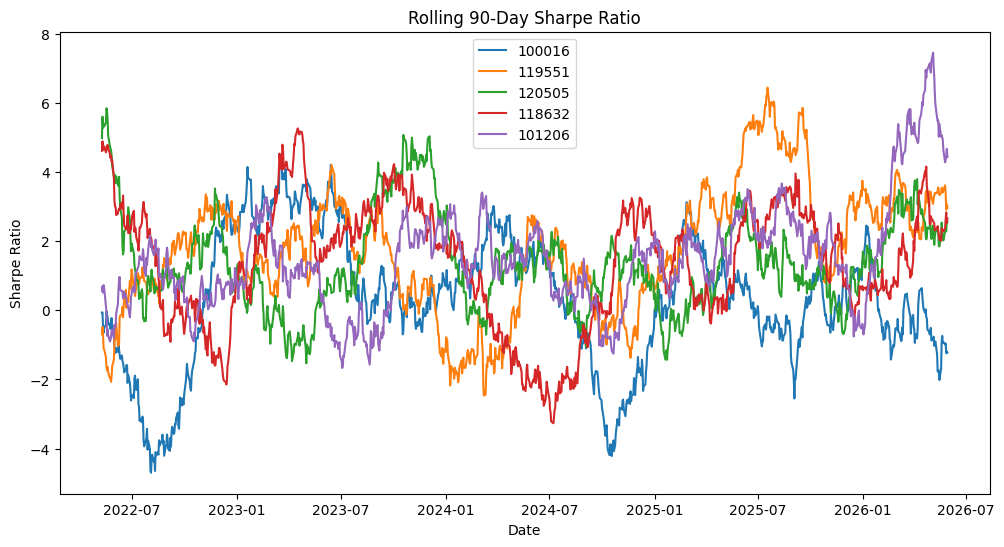

In [13]:
plt.figure(figsize=(12,6))

for fund in selected_funds:

    temp = nav[nav["amfi_code"] == fund]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.show()

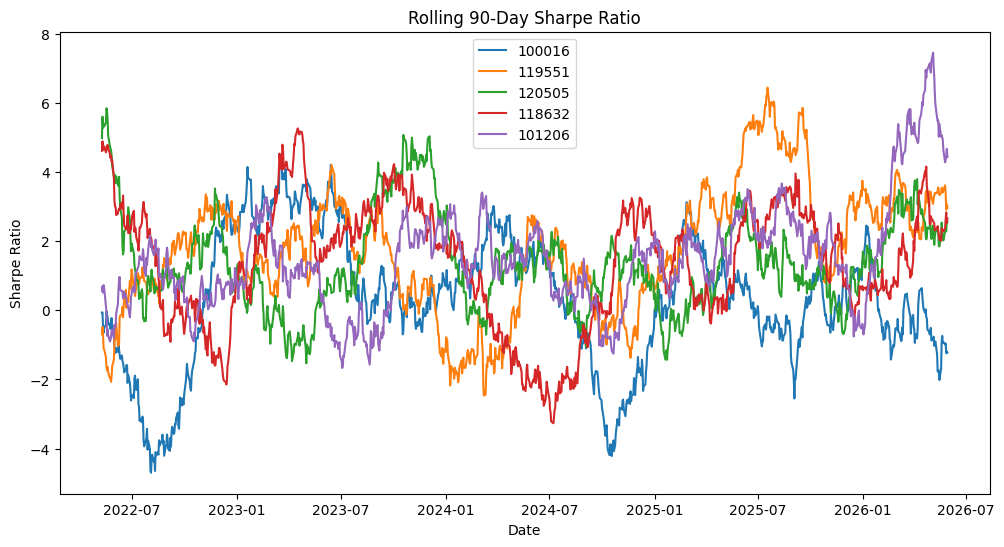

In [14]:
plt.figure(figsize=(12,6))

for fund in selected_funds:

    temp = nav[nav["amfi_code"] == fund]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig(
    "rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [15]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [16]:
first_txn = investor.groupby(
    "investor_id"
)["transaction_date"].min().reset_index()

first_txn["cohort_year"] = (
    first_txn["transaction_date"].dt.year
)

In [17]:
investor = investor.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

In [18]:
sip_data = investor[
    investor["transaction_type"] == "SIP"
]

avg_sip = sip_data.groupby(
    "cohort_year"
)["amount_inr"].mean()

avg_sip

Series([], Name: amount_inr, dtype: float64)

In [19]:
top_fund = investor.groupby(
    ["cohort_year", "amfi_code"]
).size().reset_index(name="count")

top_fund = top_fund.sort_values(
    ["cohort_year", "count"],
    ascending=[True, False]
)

top_fund.groupby(
    "cohort_year"
).head(1)

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [20]:
cohort_summary = investor.groupby(
    "cohort_year"
).agg(
    avg_investment=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    investors=("investor_id", "nunique")
)

cohort_summary

,avg_investment,total_invested,investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [21]:
# Task 4: SIP Continuity Analysis
# Filter SIP Transactions

sip_only = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip_only.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year


In [22]:
# Sort Transactions by Investor and Date

sip_only = sip_only.sort_values(
    ["investor_id", "transaction_date"]
)
# Calculate Gap Between Consecutive SIP Transactions

sip_only["previous_date"] = sip_only.groupby(
    "investor_id"
)["transaction_date"].shift(1)

sip_only["gap_days"] = (
    sip_only["transaction_date"]
    - sip_only["previous_date"]
).dt.days

sip_only.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_date,gap_days


In [23]:
# Count SIP Transactions Per Investor

sip_count = sip_only.groupby(
    "investor_id"
).size().reset_index(name="sip_count")

sip_count.head()

,investor_id,sip_count


In [24]:
# Select Investors With 6 Or More SIP Transactions

eligible_investors = sip_count[
    sip_count["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count


In [25]:
# Keep Only Eligible Investors

sip_analysis = sip_only.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

sip_analysis.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,previous_date,gap_days


In [26]:
# Calculate Average Gap For Each Investor

avg_gap = sip_analysis.groupby(
    "investor_id"
)["gap_days"].mean().reset_index()

avg_gap.head()

,investor_id,gap_days


In [27]:
# Flag At-Risk Investors

avg_gap["status"] = np.where(
    avg_gap["gap_days"] > 35,
    "At Risk",
    "Active"
)

avg_gap.head()

,investor_id,gap_days,status


In [ ]:
# Calculate SIP Continuity Summary

continuity_summary = avg_gap["status"].value_counts()

continuity_summary

Series([], Name: count, dtype: int64)

In [ ]:
# Display SIP Continuity Rate

continuity_rate = (
    (avg_gap["status"] == "Active").mean()
) * 100

print("SIP Continuity Rate:", round(continuity_rate, 2), "%")

SIP Continuity Rate: nan %


In [2]:
# Load Scheme Performance Data

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
scheme = pd.read_csv(
    "data/processed/07_scheme_performance_cleaned.csv"
)

scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [3]:
# Task 5: Fund Recommender

def recommend_funds(risk_level):

    filtered = scheme[
        scheme["risk_grade"].str.lower() == risk_level.lower()
    ]

    recommendations = filtered.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(3)

    return recommendations[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

print("Low Risk Funds")
print(recommend_funds("Low"))

print("\nModerate Risk Funds")
print(recommend_funds("Moderate"))

print("\nHigh Risk Funds")
print(recommend_funds("High"))

Low Risk Funds
                                 scheme_name risk_grade  sharpe_ratio  \
14  ICICI Pru Liquid Fund - Regular - Growth        Low          7.68   
23      Kotak Liquid Fund - Regular - Growth        Low          6.18   
30       ABSL Liquid Fund - Regular - Growth        Low          5.14   

    return_3yr_pct  
14            7.68  
23            6.18  
30            5.14  

Moderate Risk Funds
                                      scheme_name risk_grade  sharpe_ratio  \
5       HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06   
34  Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06   
11      ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03   

    return_3yr_pct  
5            14.84  
34           14.81  
11           14.41  

High Risk Funds
                                      scheme_name risk_grade  sharpe_ratio  \
21  Kotak Emerging Equity Fund - Regular - Growth       High          0.96   
12       ICICI Pr

In [5]:
# Task 6: Sector HHI Concentration

portfolio = pd.read_csv(
    "data/processed/09_portfolio_holdings_cleaned.csv"
)

scheme = pd.read_csv(
    "data/processed/07_scheme_performance_cleaned.csv"
)
portfolio["weight_sq"] = (
    portfolio["weight_pct"] / 100
) ** 2

hhi = portfolio.groupby(
    "amfi_code"
)["weight_sq"].sum().reset_index()

hhi.rename(
    columns={"weight_sq": "HHI"},
    inplace=True
)

hhi = hhi.merge(
    scheme[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

print("Top 10 Most Concentrated Funds")
print(
    hhi.sort_values(
        "HHI",
        ascending=False
    ).head(10)
)

print("\nTop 10 Most Diversified Funds")
print(
    hhi.sort_values(
        "HHI",
        ascending=True
    ).head(10)
)

Top 10 Most Concentrated Funds
    amfi_code       HHI                                        scheme_name  \
11     119092  0.206448              Axis Bluechip Fund - Regular - Growth   
3      101207  0.200700             ABSL Small Cap Fund - Regular - Growth   
18     119599  0.174751          SBI Small Cap Fund - Direct Plan - Growth   
4      102885  0.174709         UTI Nifty 50 Index Fund - Regular - Growth   
7      118632  0.168298     Nippon India Large Cap Fund - Regular - Growth   
29     148568  0.167930  Mirae Asset Emerging Bluechip Fund - Regular -...   
21     120505  0.157570           ICICI Pru Midcap Fund - Regular - Growth   
22     120506  0.153794  ICICI Pru Value Discovery Fund - Regular - Growth   
27     125498  0.152414  HDFC Mid-Cap Opportunities Fund - Direct - Growth   
23     120841  0.149680             Kotak Bluechip Fund - Regular - Growth   

           category  
11        Large Cap  
3         Small Cap  
18        Small Cap  
4             Index  


# Advanced Insights

# 1. Risk Analysis
Funds with the highest VaR and CVaR values indicate greater downside risk and are more vulnerable during adverse market conditions.

# 2. Rolling Sharpe Performance
Funds with consistently high rolling Sharpe ratios demonstrated superior risk-adjusted returns over the analysis period.

# 3. Investor Cohort Behavior
Recent investor cohorts contributed a significant share of total investments, indicating growing participation in mutual fund investments.

# 4. SIP Continuity Analysis
Most investors maintained regular SIP contributions, while investors with average gaps greater than 35 days were identified as at-risk investors.

# 5. Portfolio Concentration
Funds with higher HHI values were highly concentrated in a few sectors, whereas lower HHI values indicated better portfolio diversification.